In [1]:
!nvidia-smi

Fri Aug  1 15:19:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     On  |   00000000:CD:00.0 Off |                    0 |
|  0%   45C    P0            114W /  300W |   22083MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%cd ..

/users/5/dever120/FMPlug


## ✅ Part 1: Configuration and Setup

In this step we are simply importing the libraries needed and setting up a small configuration for regression training.

In [3]:
# third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import tqdm
from diffusers import StableDiffusion3Img2ImgPipeline
from skimage.metrics import peak_signal_noise_ratio

# first-party
from fmplug.tasks.utils import prepare_super_resolution_measurement
from fmplug.utils.measurements import get_noise, get_operator

# Configuration
image_size = 512
scale_factor = 4
epochs = 1
dtype = torch.float32

# Use CUDA if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/tmp/ipykernel_2999666/47625406.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 🖼️ Part 2: Load Image & Generate Measurement

In this step we have a function called `prepare_super_resolution_measurement`. One of the main outputs we need for this exercise is the original image, which is under `img_outputs["ref_img"]`.

In [4]:
from PIL import Image

img = Image.open("/users/5/dever120/FMPlug/data/afhq_cat.png").convert("RGB")
np.array(img).shape

(1024, 1024, 3)

In [5]:
# Load an image and simulate the measurement process
noise_sigma = 0.03
img_outputs = prepare_super_resolution_measurement(
    image_path="/users/5/dever120/FMPlug/data/afhq_cat.png",
    image_size=image_size,
    scale_factor=scale_factor,
    noise_sigma=noise_sigma,
    device=device,
    get_operator_fn=get_operator,
    get_noise_fn=get_noise,
)


## 🤖 Part 3: Load Stable Diffusion 3 Model

This is the pipeline that I have been using called `StableDiffusion3Img2ImgPipeline`. The idea is to take an image and have it transformed into a new image. This means we can start from random images or degradated images that we have available to us for inverse problems. Documentation on this pipeline can be found here: https://huggingface.co/blog/sd3#image-to-image.

For this exercise we will only extract the VAE (actually AE) encoded-decoder component. We set `.requires_grad = False` because during training we do not need the parameters of the AE to update.

In [6]:
# Load the pretrained Stable Diffusion 3 image-to-image pipeline
print("Load in SD3 image to image model ...")
pipe = StableDiffusion3Img2ImgPipeline.from_pretrained(
    "stabilityai/stable-diffusion-3-medium-diffusers",
    text_encoder_3=None,
    tokenizer_3=None,
    torch_dtype=dtype,
).to(device)


vae = pipe.vae
vae.eval()
vae.requires_grad_(False)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Load in SD3 image to image model ...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (c

## 📊 Part 4: Prepare Random Input & Encode with VAE

This is where we can encode our random image. There are actually two ways to do this:

1. We can use the `vae.encode` function which expects inputs of [-1, 1] that is specified in the `Img2Img` pipeline. 
2. We could also just use `torch.randn` explicity. We can do this because in the `Img2Img` pipeline when we are starting from pure noise the pipeline will actually just call `torch.randn`.

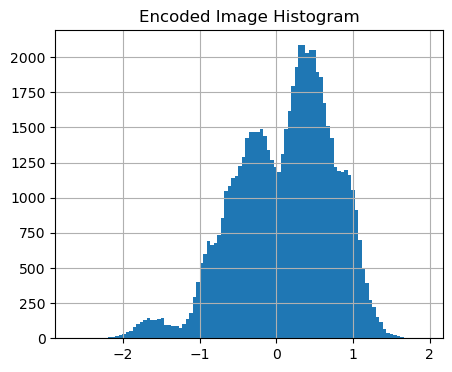

In [7]:
psnr_scores_list = []
mse_scores_list = []

# Get the reference image
original_img = img_outputs["ref_img"]
ref_img = original_img.squeeze(0).permute(1, 2, 0)
ref_img = ref_img + 0.03 * torch.randn(ref_img.shape, device=device, dtype=torch.float)
ref_img = torch.clamp((ref_img + 1.0) / 2.0, 0.0, 1.0)
ref_img = ref_img.to(device)

# # Generate a random image and normalize
# rand_img = torch.randn(original_img.shape, device=device, dtype=dtype)
# rand_img = (rand_img - rand_img.min()) / (rand_img.max() - rand_img.min())
# rand_img = (rand_img * 2.0) - 1.0

# Noisy GT
noisy_img = original_img + 0.03 * torch.randn(original_img.shape, device=device)

# Encode using the VAE
encoded_img = vae.encode(noisy_img).latent_dist.sample()

# Histogram of encoded latent vector
ax = pd.Series(encoded_img.flatten().cpu().numpy()).hist(bins=100, figsize=(5, 4))
ax.set_title("Encoded Image Histogram")
plt.show()

In [8]:
ref_img.min(), ref_img.max()

(tensor(0., device='cuda:0'), tensor(1., device='cuda:0'))

## 🧠 Part 5: Optimize the Latent Code

In this step we set `z = encoded_img` from part 4. `z` is a trainable parameter and will be the only parameter that updates during the regression training. For regression training we use the original (reference) image with no noise or degradation. 

During training we pass `z` through the decoder to get an image of size `(3, 512, 512)` (image size defined in the config) and take the MSE against the original image.

The metric that we track here PSNR.

In [9]:
# Goal: Optimize the latent code z to match decoded image to reference
z = torch.randn(encoded_img.shape, device=device, dtype=torch.float32)
z = z.requires_grad_(True)

# z = encoded_img.requires_grad_(True)

# z = torch.nn.Parameter(encoded_img.clone())
optimizer = torch.optim.Adam([z], lr=1e-2)

for epoch in tqdm.tqdm(range(epochs)):
    optimizer.zero_grad()

    decoded_img = vae.decode(z).sample
    decoded_img = decoded_img.squeeze(0).permute(1, 2, 0)
    decoded_img = torch.clamp((decoded_img + 1.0) / 2.0, 0, 1)

    loss = ((ref_img - decoded_img) ** 2).mean()

    loss.backward()
    optimizer.step()

    with torch.no_grad():
        psnr_score = peak_signal_noise_ratio(
            ref_img.cpu().numpy(), decoded_img.detach().cpu().numpy()
        )
        psnr_scores_list.append(psnr_score)
        mse_scores_list.append(loss.item())

print(np.max(psnr_scores_list))

100%|██████████| 1/1 [00:00<00:00,  2.94it/s]

5.93857353134716


## 🎨 Part 6: Visualize & Compare Results

In this part we show the inputs and outputs of the regression model with decoder only.

1. The original image and its histogram
2. We show the random image input and its histogram
3. We show the histogram of the encoded values - this helps us get a sense of what distributions looks like in the encoded space
4. We show the trained decoded image and the histogram of the trained decoded image.

We can compare the distributions of (1) and (4) and we see that the trained distribution is more smooth than the original. From the previous cell we also get a max PSNR score.

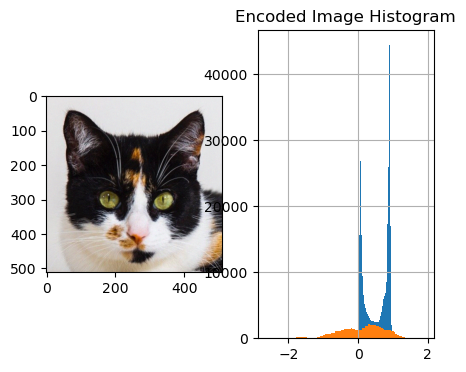

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7798748..2.5183232].


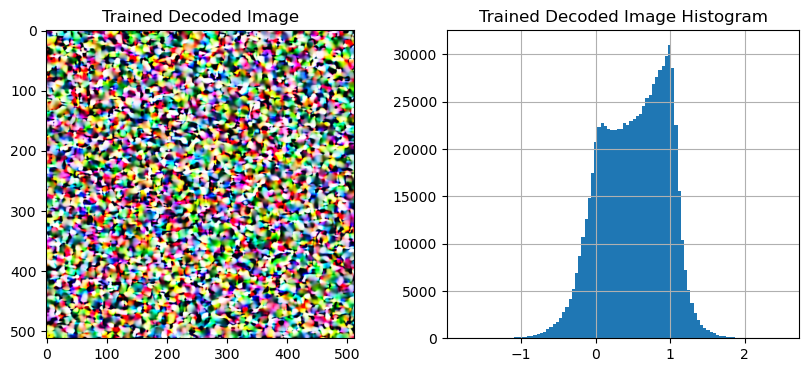

In [10]:
# Histogram of the original image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(ref_img.detach().cpu().numpy())

pd.Series(ref_img.detach().cpu().numpy().flatten()).hist(bins=100, ax=ax2)
ax2.set_title("Original Image Histogram")

# Decode the optimized latent vector
trained_decoded_img = vae.decode(z).sample
trained_decoded_img = (
    trained_decoded_img.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
)
trained_decoded_img = (trained_decoded_img + 1.0) / 2.0

# # Original random input image
# original_rand_img = (rand_img.squeeze(0).permute(1, 2, 0).cpu().numpy() + 1.0) / 2.0

# # Compare visually
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
# ax1.imshow(original_rand_img)
# ax1.set_title("Random Image")
# pd.Series(original_rand_img.flatten()).hist(bins=100, ax=ax2)
# ax2.set_title("Random Image Histogram")
# plt.show()

# Histogram of encoded latent vector
ax = pd.Series(encoded_img.flatten().cpu().numpy()).hist(bins=100, figsize=(5, 4))
ax.set_title("Encoded Image Histogram")
plt.show()

# Trained decoded image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(trained_decoded_img)
ax1.set_title("Trained Decoded Image")
pd.Series(trained_decoded_img.flatten()).hist(bins=100, ax=ax2)
ax2.set_title("Trained Decoded Image Histogram")
plt.show()

<Axes: >

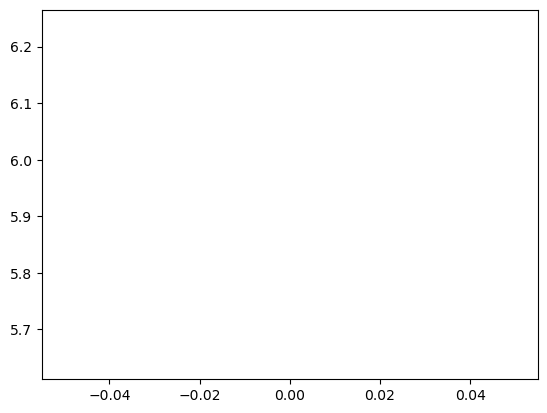

In [11]:
pd.Series(psnr_scores_list).plot()

# ⚡️ Part 7: Encoder - Decoder Only

1. GT - Encoder - Decoder - Output
2. Noisy GT - Encoder - Decoder - Output

In [12]:
original_img = img_outputs["ref_img"]
original_img = original_img + 0.03 * torch.randn(original_img.shape, device=device)

encoded_img = vae.encode(original_img).latent_dist.sample() 
decoded_img = vae.decode(encoded_img).sample

In [13]:
import lpips

lpips_loss_fn = lpips.LPIPS(net="vgg").to(device)

lpips_loss = lpips_loss_fn(original_img, decoded_img).item()

# Get the PSNR for the decoder - encoder
original_img = original_img.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
decoded_img = decoded_img.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()

original_img = np.clip((original_img + 1.0) / 2.0, 0.0, 1.0)
decoded_img = np.clip((decoded_img + 1.0) / 2.0, 0.0, 1.0)

print(
    peak_signal_noise_ratio(original_img, decoded_img),
    lpips_loss,
)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/users/5/dever120/.conda/envs/materialmind/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/users/5/dever120/.conda/envs/materialmind/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /users/5/dever120/.conda/envs/materialmind/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth
32.26905369858997 0.09174095094203949


/users/5/dever120/.conda/envs/materialmind/lib/python3.12/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(mod

Text(0.5, 1.0, 'Original Image Histogram')

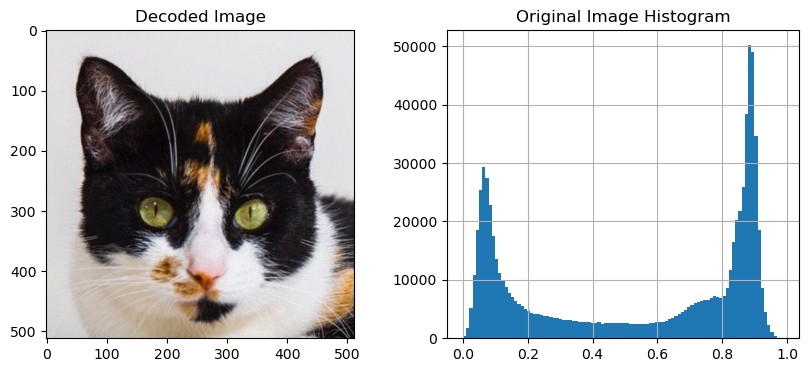

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(decoded_img)
ax1.set_title("Decoded Image")

pd.Series(decoded_img.flatten()).hist(bins=100, ax=ax2)
ax2.set_title("Original Image Histogram")

Text(0.5, 1.0, 'Encoded Image Histogram')

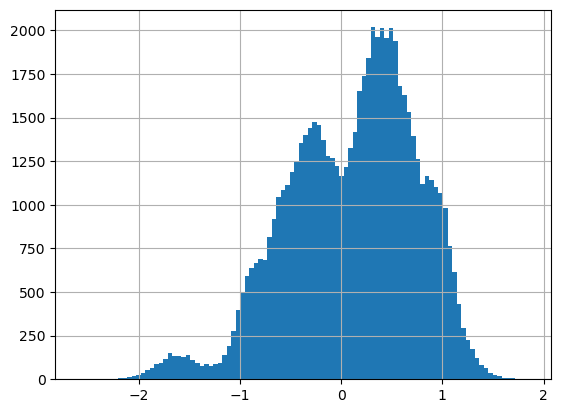

In [15]:
pd.Series(encoded_img.detach().cpu().numpy().flatten()).hist(bins=100)
ax2.set_title("Encoded Image Histogram")

Text(0.5, 1.0, 'Original Image Histogram')

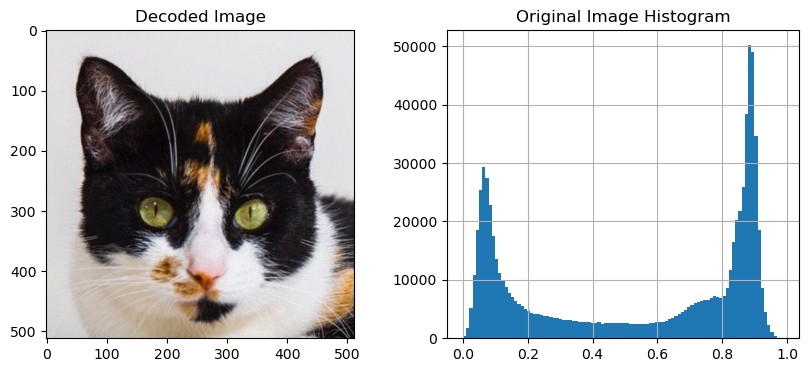

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(decoded_img)
ax1.set_title("Decoded Image")

pd.Series(decoded_img.flatten()).hist(bins=100, ax=ax2)
ax2.set_title("Original Image Histogram")